<a href="https://colab.research.google.com/github/Coder0469/Do-an-1/blob/main/Week5/DenseUnet_Pascal_VOC_2012_ggcolab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

# gopalbhattrai_pascal_voc_2012_dataset_path = kagglehub.dataset_download('gopalbhattrai/pascal-voc-2012-dataset')
# hillsp_denseunet_pytorch_default_1_path = kagglehub.model_download('hillsp/denseunet/PyTorch/default/1')
# hillsp_denseunet_pytorch_default_2_path = kagglehub.model_download('hillsp/denseunet/PyTorch/default/2')
# hillsp_denseunet_pytorch_default_3_path = kagglehub.model_download('hillsp/denseunet/PyTorch/default/3')
# hillsp_denseunet_pytorch_default_4_path = kagglehub.model_download('hillsp/denseunet/PyTorch/default/4')

# print('Data source import complete.')


<a href="https://colab.research.google.com/github/Coder0469/Do-an-1/blob/main/Week3/B2_basic_pipeline_PASCALVOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h3>Kiểm tra GPU được cấp phát</h3>
</div>

In [3]:
!nvidia-smi

Tue Oct 21 13:08:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install timm

<div class="markdown-google-sans">
  <h3>Cài đặt bổ sung một số thư viện</h3>
</div>
Nền tảng Google Colab cung cấp môi trường với các thư viện Machine Learning, Deep Learning cơ bản đã được cài đặt sẵn, phần này sẽ cài đặt một số thư viện sử dụng thêm.

In [5]:
!pip install segmentation_models_pytorch
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.9 MB/s eta 0:00:00


<div class="markdown-google-sans">
  <h3></h3>
</div>


<div class="markdown-google-sans">
  <h3>Import thư viện</h3>
</div>

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchmetrics
from torchmetrics import  JaccardIndex
from torchmetrics.segmentation import DiceScore
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor
import os
from tqdm import tqdm
from glob import glob
# from torchvision.datasets import VOCSegmentation
import timm

<div class="markdown-google-sans">
  <h3>Định nghĩa Dataset</h3>
</div>
Viết class kế thừa từ class Dataset cung cấp sẵn trong PyTorch để đọc dữ liệu từ ổ cứng. Yêu cầu viết đủ 3 hàm __init__() để khởi tạo class, __len__() để trả về số điểm dữ liệu có trong tập dữ liệu và __getitem__() trả về 1 điểm dữ liệu cụ thể. Trong phần này, do tập dữ liệu PASCAL VOC đã rất phổ biến nên sẽ tận dụng Class Dataset đã được viết sẵn. Tham khảo thêm: https://albumentations.ai/docs/autoalbument/examples/pascal_voc/


In [7]:
kaggle_path = "/kaggle/input/pascal-voc-2012-dataset"

In [8]:
drive_path = "/content/drive/MyDrive/pascal_voc_2012/VOC2012_train_val/VOC2012_train_val"

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(500, 486, 3)


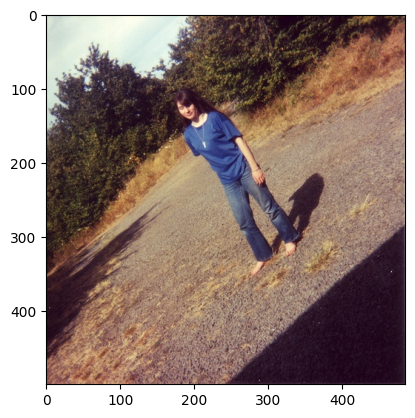

In [11]:

img = cv2.imread(f"/{drive_path}/JPEGImages/2007_000027.jpg")
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img)

In [12]:
trainsize = 256

train_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.HorizontalFlip(),
    A.RandomBrightnessContrast(),
    A.Blur(),
    A.Sharpen(),
    # A.RGBShift(),
    # A.Cutout(num_holes=5, max_h_size=25, max_w_size=25, fill_value=0),
    A.CoarseDropout(
        max_holes=8,          # Maximum number of holes (cutout regions)
        max_h_size=64,        # Maximum height of a hole
        max_w_size=64,        # Maximum width of a hole
        fill_value=0,         # Value to fill the holes with (e.g., 0 for black)
        p=0.5                 # Probability of applying CoarseDropout
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(), # numpy.array -> torch.tensor (B, 3, H, W)
])

/tmp/ipython-input-2514797767.py:11: UserWarning: Argument(s) 'max_holes, max_h_size, max_w_size, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [13]:
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "potted plant",
    "sheep",
    "sofa",
    "train",
    "tv/monitor",
]

VOC_COLORMAP = [
    [0, 0, 0],
    [128, 0, 0],
    [0, 128, 0],
    [128, 128, 0],
    [0, 0, 128],
    [128, 0, 128],
    [0, 128, 128],
    [128, 128, 128],
    [64, 0, 0],
    [192, 0, 0],
    [64, 128, 0],
    [192, 128, 0],
    [64, 0, 128],
    [192, 0, 128],
    [64, 128, 128],
    [192, 128, 128],
    [0, 64, 0],
    [128, 64, 0],
    [0, 192, 0],
    [128, 192, 0],
    [0, 64, 128],
]

In [14]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, root_dir, label_dir,txt_file=None, transform=None):
        super().__init__()
        self.root_dir = root_dir
        self.label_dir = label_dir
        self.transform = transform
        self.list_img = []
        self.txt_file = txt_file
        with open(self.txt_file, 'r') as file_in:
            for line in file_in:
                self.list_img.append(line.strip())

    def __len__(self):
        return len(self.list_img)

    @staticmethod
    def _convert_to_segmentation_mask(mask):
        # This function converts a mask from the Pascal VOC format to the format required by AutoAlbument.
        #
        # Pascal VOC uses an RGB image to encode the segmentation mask for that image. RGB values of a pixel
        # encode the pixel's class.
        #
        # AutoAlbument requires a segmentation mask to be a NumPy array with the shape [height, width, num_classes].
        # Each channel in this mask should encode values for a single class. Pixel in a mask channel should have
        # a value of 1.0 if the pixel of the image belongs to this class and 0.0 otherwise.
        height, width = mask.shape[:2]
        segmentation_mask = np.zeros((height, width, len(VOC_COLORMAP)), dtype=np.float32)
        for label_index, label in enumerate(VOC_COLORMAP):
            segmentation_mask[:, :, label_index] = np.all(mask == label, axis=-1).astype(float)
        return segmentation_mask #0, 1, 2, 3, ..., 20 (H, W, C) -> (H, W, 1) -> (H, W) #numpy

    def __getitem__(self, idx):
        img_name = self.list_img[idx]
        img_path = os.path.join(self.root_dir, f"{img_name}.jpg")
        mask_path = os.path.join(self.label_dir, f"{img_name}.png")

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = self._convert_to_segmentation_mask(mask)
        # Ensure mask values are within the valid range [0, num_classes - 1]
        # Assuming 12 classes (0-11) based on model setup
        # mask[mask >= 12] = 0 # Map invalid indices to 0

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        else:
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
            mask = torch.from_numpy(mask).long()

        # Print unique mask values after transformation for debugging
        # print(f"Unique mask values after transform: {torch.unique(mask)}")

        return image, mask.argmax(dim=2).squeeze()

387


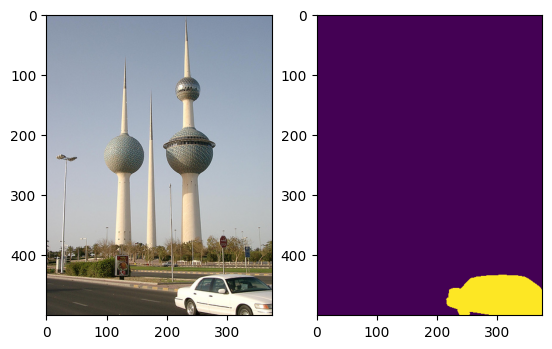

torch.Size([500, 375])
tensor([0, 7])


In [15]:
import random
train_dataset = MyDataset(f"{drive_path}/JPEGImages",
                          f"{drive_path}/SegmentationClass",
                          f"{drive_path}/ImageSets/Segmentation/train.txt")
id = random.randint(0, train_dataset.__len__()) # Added 0 as the lower bound
img,mask = train_dataset.__getitem__(id)
print(id)
plt.subplot(121);plt.imshow(img.permute(1,2,0))
plt.subplot(122);plt.imshow(mask)
plt.show()
print(mask.shape)
print(torch.unique(mask.reshape(1,-1)))

<div class="markdown-google-sans">
  <h3>Định nghĩa các phép augmentation trên ảnh</h3>
</div>
Sử dụng thư viện Albumentations, tham khảo thêm: https://albumentations.ai/docs/api_reference/full_reference/

<div class="markdown-google-sans">
  <h3>Đoạn code dùng để convert ảnh sau khi đã chuẩn hoá thành ảnh ban đầu</h3>
</div>

In [16]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor

unorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

<div class="markdown-google-sans">
  <h3>Kiểm tra 1 cặp ảnh đầu vào và ảnh kết quả phân vùng trước khi đưa vào mô hình training</h3>
</div>

tensor([ 0, 19])


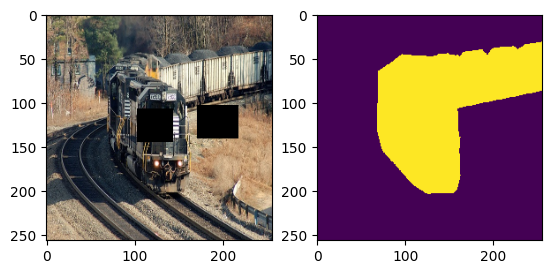

In [17]:
# train_dataset = PascalVOCSearchDataset(image_set="train", download=True, transform=train_transform)
# test_dataset = PascalVOCSearchDataset(image_set="val", download=False, transform=test_trainsform)
train_dataset = MyDataset(f"{drive_path}/JPEGImages",
                          f"{drive_path}/SegmentationClass",
                          f"{drive_path}/ImageSets/Segmentation/train.txt",
                            train_transform)
val_dataset = MyDataset(f"{drive_path}/JPEGImages",
                          f"{drive_path}/SegmentationClass",
                          f"{drive_path}/ImageSets/Segmentation/val.txt",
                          test_transform)
image, mask = train_dataset.__getitem__(10)
print(torch.unique(mask.reshape(1,-1)))
plt.subplot(1, 2, 1)
plt.imshow(unorm(image).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.show()

<div class="markdown-google-sans">
  <h3>Lập trình mô hình UNet cơ bản</h3>
</div>

In [18]:
#model UNet

def unet_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, 1, 1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 3, 1, 1),
        nn.ReLU()
    )

class DenseUnet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes
        self.backbone = timm.create_model('densenet121', pretrained=False,features_only=True)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear")
        self.block_neck = unet_block(1024, 1024)
        self.block_up1 = unet_block(1024+1024, 512)
        self.block_up2 = unet_block(512+512, 256)
        self.block_up3 = unet_block(256+256, 128)
        self.block_up4 = unet_block(64+128, 64)
        self.conv_cls = nn.Conv2d(64, self.n_classes, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.backbone(x)
        #x1 (B, 64, 128, 128) size/2
        #x2 (B, 256, 64, 64) size/4
        #x3 (B, 512, 32, 32) size/16
        #x4 (B, 1024, 16, 16) size/32
        #x5 (B, 2048, 8, 8) size/64
        x = self.block_neck(x5) # x (B, 1024, 8, 8)
        x = self.dropout(x)
        x = torch.cat([x4, self.upsample(x)], dim=1)
        x = self.block_up1(x)
        x = self.dropout(x)
        x = torch.cat([x3, self.upsample(x)], dim=1)
        x = self.block_up2(x)
        x = self.dropout(x)
        x = torch.cat([x2, self.upsample(x)], dim=1)
        x = self.block_up3(x)
        x = self.dropout(x)
        x = torch.cat([x1, self.upsample(x)], dim=1)
        x = self.block_up4(x)
        x = self.dropout(x)
        x = self.conv_cls(x) #size/2
        x = self.upsample(x)
        return x


<div class="markdown-google-sans">
  <h3>Tạo AverageMeter</h3>
</div>
AverageMeter có nhiệm vụ lưu lại giá trị trung bình của độ chính xác, giá trị hàm loss, ... trong suốt quá trình training. Tham khảo thêm: https://discuss.pytorch.org/t/meaning-of-parameters/10655

In [19]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

<div class="markdown-google-sans">
  <h3>Lập trình hàm tính toán độ chính xác</h3>
</div>

In [20]:
#accuracy fn
def accuracy_function(preds, targets):
    preds_flat = preds.flatten()
    targets_flat = targets.flatten()
    acc = torch.sum(preds_flat == targets_flat)
    return acc/targets_flat.shape[0]

<div class="markdown-google-sans">
  <h3>Chuẩn bị cho quá trình training</h3>
</div>


1.   Lựa chọn device: PyTorch yêu cầu lựa chọn cụ thể device sẽ train và yêu cầu người dùng tự move dữ liệu, mô hình vào device đã lựa chọn. Device có thể là "cuda" - tức là GPU NVIDIA hoặc "cpu".
2.   Định nghĩa DataLoader, khác với Dataset là cách đọc dữ liệu từ ổ cứng, DataLoader ghép nhiều điểm dữ liệu vào cùng nhau tạo thành 1 batch để đưa vào train mô hình. Lưu ý thêm: batch_size nên đặt là 4, 8, 16, 32, ... và nên để lớn nhất có thể
3.   Khởi tạo mô hình
4.   Khởi tạo hàm loss
5.   Khởi tạo thuật toán tối ưu (optimizer)
6.   Khởi tạo các độ đo sẽ sử dụng để đánh giá hiệu năng của mô hình. Phần này sẽ sử dụng các hàm độ đo Dice và IoU được lập trình sẵn trong thư viện torchmetrics
7.   Khởi tạo từng AverageMeter để lưu lại giá trị của từng độ đo, giá trị hàm loss, thời gian train, ... trong suốt quá trình train



In [21]:
def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [28]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#load data
batch_size = 16
n_workers = os.cpu_count()

print("num_workers =", n_workers)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=n_workers)
testloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers=n_workers)

#model
model = DenseUnet(21).to(device) # Changed num_classes to 11

#loss
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
n_eps = 120

#metrics
# dice_fn = DiceScore(num_classes=21, average="macro").to(device) # Changed num_classes to 12
# iou_fn = torchmetrics.JaccardIndex(num_classes=21, task="multiclass", average="macro").to(device) # Changed num_classes to 12

#meter
train_loss_meter = AverageMeter()
intersection_meter = AverageMeter()
union_meter = AverageMeter()
target_meter = AverageMeter()
acc_meter = AverageMeter()

val_loss_meter = AverageMeter()
val_intersection_meter = AverageMeter()
val_union_meter = AverageMeter()
val_target_meter = AverageMeter()
val_acc_meter = AverageMeter()

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


num_workers = 2


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseUnet(21).to(device)
state_dict = torch.load("/content/drive/MyDrive/pascal_voc_2012/VOC2012_train_val/modelDenseUNet.pth")

# Load the state dictionary into the model
model.load_state_dict(state_dict)

print("Model loaded successfully!")

Model loaded successfully!


<div class="markdown-google-sans">
  <h3>Training thôi ...</h3>
</div>
Tham khảo thêm cách viết code training trong PyTorch: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [ ]:
for ep in range(1, 1+n_eps):
    train_loss_meter.reset()
    acc_meter.reset()
    intersection_meter.reset()
    union_meter.reset()
    target_meter.reset()

    for batch_id, (x, y) in enumerate(tqdm(trainloader), start=1):
        model.train()
        optimizer.zero_grad()
        n = x.shape[0]
        x = x.to(device).float()
        y = y.to(device).long()
        y_hat = model(x) #(B, C, H, W)
        loss = criterion(y_hat, y) #(B, C, H, W) >< (B, H, W)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            y_hat_mask = y_hat.argmax(dim=1).squeeze() # (B, C, H, W) -> (B, 1, H, W) -> (B, H, W)
            intersection, union, target = intersectionAndUnionGPU(y_hat_mask.float(), y.float(), 21)

            train_loss_meter.update(loss.item(), n)
            intersection_meter.update(intersection)
            union_meter.update(union)
            target_meter.update(target)
            accuracy = accuracy_function(y_hat_mask, y.long())
            acc_meter.update(accuracy.item(), n)

    with torch.no_grad():
        iou_class = intersection_meter.sum / (union_meter.sum + 1e-10) #vector 21D
        dice_class = (2 * intersection_meter.sum) / (intersection_meter.sum + union_meter.sum + 1e-10) #vector 21D

        mIoU = torch.mean(iou_class) #mean vector 21D
        mDice = torch.mean(dice_class) #mean vector 21D

    print("EP {}, accuracy = {} train loss = {} IoU = {}, dice = {}".format(ep,acc_meter.avg, train_loss_meter.avg, mIoU, mDice))

    torch.save(model.state_dict(), "/content/drive/MyDrive/pascal_voc_2012/VOC2012_train_val/modelDenseUNet.pth")
    train_losses.append(train_loss_meter.avg)
    train_accuracies.append(acc_meter.avg)




100%|██████████| 92/92 [03:44<00:00,  2.44s/it]


EP 1, accuracy = 0.9488734782067805 train loss = 0.15867970517424287 IoU = 0.7801727056503296, dice = 0.8726941347122192


100%|██████████| 92/92 [03:54<00:00,  2.55s/it]


EP 2, accuracy = 0.948241937355917 train loss = 0.16230914322404913 IoU = 0.7765109539031982, dice = 0.8699623346328735


100%|██████████| 92/92 [03:52<00:00,  2.53s/it]


...

100%|██████████| 92/92 [03:49<00:00,  2.50s/it]


EP 54, accuracy = 0.9487018064071572 train loss = 0.1614086352736572 IoU = 0.7818814516067505, dice = 0.8732190132141113


100%|██████████| 92/92 [03:49<00:00,  2.50s/it]


EP 55, accuracy = 0.9490739269986179 train loss = 0.15930058192359944 IoU = 0.7796958088874817, dice = 0.8716517090797424


 87%|████████▋ | 80/92 [03:18<00:25,  2.09s/it]

In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.title('Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:


model.eval()
val_acc_meter.reset()

for batch_id, (x, y) in enumerate(tqdm(testloader), start=1):
    n = x.shape[0]
    x = x.to(device).float()
    y = y.to(device).long()
    y_hat = model(x) #(B, C, H, W)
    loss = criterion(y_hat, y) #(B, C, H, W) >< (B, H, W)


    with torch.no_grad():
        y_hat_mask = y_hat.argmax(dim=1).squeeze() # (B, C, H, W) -> (B, 1, H, W) -> (B, H, W)
        accuracy = accuracy_function(y_hat_mask, y.long())
        intersection, union, target = intersectionAndUnionGPU(y_hat_mask.float(), y.float(), 21)

        val_loss_meter.update(loss.item(), n)
        val_intersection_meter.update(intersection)
        val_union_meter.update(union)
        val_acc_meter.update(accuracy.item(),n)
        val_target_meter.update(target)

with torch.no_grad():
    iou_class = val_intersection_meter.sum / (val_union_meter.sum + 1e-10) #vector 21D
    dice_class = (2 * val_intersection_meter.sum) / (val_intersection_meter.sum + val_union_meter.sum + 1e-10) #vector 21D

    mIoU = torch.mean(iou_class) #mean vector 21D
    mDice = torch.mean(dice_class) #mean vector 21D

print("test loss = {}, accuracy = {}, IoU = {}, dice = {}".format(
    val_loss_meter.avg, val_acc_meter.avg, mIoU, mDice
))

<div class="markdown-google-sans">
  <h3>Viết code hiển thị kết quả dự đoán</h3>
</div>

In [ ]:
#predict

for i in range(0,20):
    with torch.no_grad():
        model.eval()
        x, y = val_dataset.__getitem__(i)
        y_predict = model(x.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
        for i in np.unique(y_predict).tolist():
            print(VOC_CLASSES[i])
        color_mask_predict = np.zeros((*y_predict.shape, 3))
        for i, color in enumerate(VOC_COLORMAP):
            color_mask_predict[y_predict==i] = np.array(color)
        color_mask = np.zeros((*y_predict.shape, 3))
        for i, color in enumerate(VOC_COLORMAP):
            color_mask[y==i] = np.array(color)
        plt.subplot(1,3,1)
        plt.imshow(unorm(x).permute(1, 2, 0))
        plt.subplot(1,3,2)
        plt.imshow(color_mask)
        plt.subplot(1,3,3)
        plt.imshow(color_mask_predict)
        plt.show()

## VISUALIZE!!